# Tiny Shakespeare Dataset - Fine-Tuning a Pretrained LLM

### [Tiny Shakespeare Dataset](https://github.com/karpathy/char-rnn)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Andrej Karpathy, https://github.com/karpathy/char-rnn

[2] Alec Radford et al., https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

[3] Hugging Face Transformers, https://huggingface.co/docs/transformers

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# pip install transformers
# conda install numpy matplotlib

## Import Libraries

In [2]:
import urllib.request
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import GPT2LMHeadModel
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
MODEL_NAME = 'distilgpt2'
MODEL_NAME

'distilgpt2'

In [6]:
BLOCK_SIZE = 128
BLOCK_SIZE

128

## Hyperparameters

In [7]:
LEARNING_RATE = 0.00005
LEARNING_RATE

5e-05

In [8]:
EPOCHS = 2
EPOCHS

2

In [9]:
BATCH_SIZE = 16
BATCH_SIZE

16

## Device

In [10]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Download Dataset

In [11]:
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(URL, 'data/tinyshakespeare.txt')
with open('data/tinyshakespeare.txt', encoding='utf-8') as handle:
    text = handle.read()
print('length:', len(text))

length: 1115394


## Tokenize Dataset

The GPT-2 tokenizer splits text into subword tokens. We concatenate the token ids and cut them into fixed-length blocks.

In [12]:
def tokenize_blocks(tokenizer, text, block_size):
    """
    Tokenize text and cut it into fixed-length blocks.

    Parameters:
        tokenizer (GPT2TokenizerFast): The tokenizer.
        text (str): The training text.
        block_size (int): Length of each block.

    Returns:
        torch.Tensor: A 2-D tensor of token ids.
    """
    ids = tokenizer(text)['input_ids']
    n_blocks = len(ids) // block_size
    trimmed = ids[:n_blocks * block_size]
    return torch.tensor(trimmed, dtype=torch.long).view(n_blocks, block_size)

### Run

In [13]:
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
blocks = tokenize_blocks(tokenizer, text, BLOCK_SIZE)
blocks.shape

Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


torch.Size([2640, 128])

## Create Dataset and DataLoader

In [14]:
class TextDataset(torch.utils.data.Dataset):
    """
    A dataset of fixed-length token blocks.
    """

    def __init__(self, blocks):
        """
        Store the token blocks.

        Parameters:
            blocks (torch.Tensor): A 2-D tensor of token ids.

        Returns:
            None
        """
        self.blocks = blocks

    def __len__(self):
        """
        Return the number of blocks.

        Parameters:
            None

        Returns:
            int: Number of blocks.
        """
        return len(self.blocks)

    def __getitem__(self, idx):
        """
        Return one block as input and target.

        Parameters:
            idx (int): Block index.

        Returns:
            tuple: Input and target tensors.
        """
        block = self.blocks[idx]
        return block, block.clone()

In [15]:
split = int(0.9 * len(blocks))
train_loader = DataLoader(TextDataset(blocks[:split]), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TextDataset(blocks[split:]), batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(val_loader)

(149, 17)

## Load Pretrained Model

We start from DistilGPT-2, a small pretrained language model, and fine-tune it on Shakespeare. This is far cheaper than training from scratch.

In [16]:
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
sum(p.numel() for p in model.parameters())

81912576

## Train Model

### Functions

In [17]:
def train_epoch(model, loader, optimizer):
    """
    Fine-tune the model for a single epoch.

    Parameters:
        model (nn.Module): The language model.
        loader (DataLoader): Training data loader.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=x, attention_mask=(x != tokenizer.pad_token_id).long(),
                        labels=y)
        outputs.loss.backward()
        optimizer.step()
        total += outputs.loss.item() * len(x)
    return total / len(loader.dataset)


def estimate_loss(model, loader):
    """
    Estimate the mean loss over a loader.

    Parameters:
        model (nn.Module): The language model.
        loader (DataLoader): Evaluation data loader.

    Returns:
        float: Mean loss.
    """
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(input_ids=x, attention_mask=(x != tokenizer.pad_token_id).long(),
                            labels=y)
            total += outputs.loss.item() * len(x)
    return total / len(loader.dataset)

### Training Loop

In [18]:
history = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss = estimate_loss(model, val_loader)
    history.append(val_loss)
    print(f"Epoch {epoch + 1} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

Epoch 1 | train loss 4.0547 | val loss 3.7482


Epoch 2 | train loss 3.7320 | val loss 3.6898


### Visualize Training

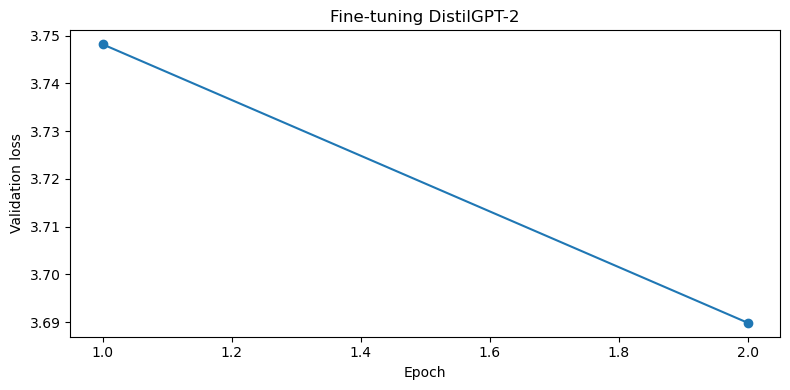

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Fine-tuning DistilGPT-2')
plt.tight_layout()
plt.show()

## Generate Text

### Function

In [20]:
def generate(model, prompt, max_new_tokens=100):
    """
    Generate text from a prompt.

    Parameters:
        model (nn.Module): Fine-tuned language model.
        prompt (str): Seed text.
        max_new_tokens (int): Number of tokens to generate.

    Returns:
        str: The generated text.
    """
    model.eval()
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                do_sample=True, top_k=50, temperature=0.8,
                                pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(output[0], skip_special_tokens=True)

### Run

In [21]:
print(generate(model, 'ROMEO: ', max_new_tokens=120))

ROMEO: _______

ROMEO:
Nay, I have forgot.

ROMEO:
O, I forgot.

ROMEO:
I forgot.
COMINIUS:
I'll prove you wrong.

ROMEO:
Hear me yet?

ROMEO:
Yea, so, what is the purpose of the law?

ROMEO:
Nay, it is a law, and the law is.

ROMEO:
Hear me yet?

ROMEO:
Thou art not but a law


## Save Model

In [22]:
model.save_pretrained('models/distilgpt2_shakespeare')
tokenizer.save_pretrained('models/distilgpt2_shakespeare')
print('saved distilgpt2_shakespeare')

saved distilgpt2_shakespeare


## Load Model

In [23]:
loaded_model = GPT2LMHeadModel.from_pretrained('models/distilgpt2_shakespeare').to(DEVICE)
loaded_model.eval()
print('loaded distilgpt2_shakespeare')

loaded distilgpt2_shakespeare


## Inference

In [24]:
print(generate(loaded_model, 'JULIET: ', max_new_tokens=120))

JULIET: ix

GLOUCESTER:
Well, I think it must be true, my lord.

JULIET:
I would, sir, I would, sir, have seen the man
Of a gentleman's face I had not seen.

GLOUCESTER:
You, sir?

JULIET:
That is the gentleman's face, sir, and that he
Is not
The man's face, sir.

JULIET:
I do remember the man; and you, sir,
What
